Importacion de librerias para tratamiento y limpieza de datos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ruta_carpeta = '/data/processed/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Tratamiento y limpieza de datos para dataset de IDH COL Subnacional

In [ ]:
# Configurar matplotlib para tener mejores diseños
plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['font.size'] = 10

# Leer mi documento
idh_df = pd.read_excel('/data/raw//idhsubnacionalcol2011-2022.xlsx')
print('Cabecera de los datos')
print("")
print(idh_df.head())
print("")
print("- Información general de los datos")
print("")
print(idh_df.info())
print("")

# Validar si tengo valores nulos
print('Recuento devalores nulos')
print(idh_df.isnull().sum())

#arreglo de cabecera
idh_df.columns = (
    idh_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_',regex=False)
)

print(idh_df.head())
print("- Información general de los datos")
print("")
print(idh_df.info())

idh_df.to_csv(f'{ruta_carpeta}idh_dataset_clean.csv', index=False, encoding='utf-8-sig')

Los datos de idh ya se encuentran depurados, no es necesario realizar limpieza alguna

Tratamiento y limpieza de datos para dataset de matriculacion educacion (basica hasta media) COL, datos micro

In [ ]:
# Configuracion de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Configurar matplotlib para tener mejores diseños
plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['font.size'] = 10

# Leer mi documento
matricula_b5_df = pd.read_csv('/data/raw/matriculacion_bottom5.csv')
print('Cabecera de los datos')
print("")
print(matricula_b5_df.head())
print("")
print("- Información general de los datos")
print("")
print(matricula_b5_df.info())
print("")

#imputar los valores
# Validar si tengo valores nulos
print('Recuento devalores nulos')
print(matricula_b5_df.isnull().sum())

#arreglo de cabecera
matricula_b5_df.columns = (
    matricula_b5_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_',regex=False)
)

# Eliminacion de columnas prescindibles para el analisis
"""
Se eliminaran las columnas: columnas relacionadas con el establecimiento o sede de la matriculacion pues estos no son pertinentes para el analisis macro que se plantea
 (a excepcion del tipo de esablecimiento), las columnas relativas a la secretaria puesto que esa data suele ser la misma en relacion al departamento o municipio siendo redundante,
 la informacion relativa a los detalles de la institucion  (calendario, jornada, metodoligia, caracter, especialidad)
"""
# lista con las columnas a preservar
pertinentColumns = [
    "anno_inf",
    "cod_dane_departamento",
    "departamento",
    "cod_dane_municipio",
    "municipio",
    "cod_zona",
    "zona",
    "cod_grado",
    "grado",
    "edad",
    "cod_genero",
    "genero",
    "cod_grupo_etnico",
    "grupo_etnico",
]
# depuracion de dataframe con las columnas a mantener
matricula_b5_df = matricula_b5_df[pertinentColumns]
print(matricula_b5_df.head())
print("- Información general de los datos")
print("")
print(matricula_b5_df.info())

#Revision de datos nulos despues de depuracion de columnas
print('Recuento devalores nulos')
print(matricula_b5_df.isnull().sum())

print(matricula_b5_df['departamento'])

#eliminacion de años fuera del scope (2023 y 2024)
matricula_b5_df = matricula_b5_df[matricula_b5_df['anno_inf'].isin(range(2011, 2023))]
print(sorted(matricula_b5_df['anno_inf'].unique()))

matricula_b5_df.to_csv(f'{ruta_carpeta}matriculacion_dataset_clean.csv', index=False, encoding='utf-8-sig')

/tmp/ipykernel_16168/2378473366.py:11: DtypeWarning: Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.
  matricula_b5_df = pd.read_csv('/content/drive/MyDrive/idhcolsubnacional/matriculacion_bottom5.csv')


Cabecera de los datos

   ANNO_INF  COD_DANE_DEPARTAMENTO DEPARTAMENTO  COD_SECRETARIA  SECRETARIA  \
0      2011                     44      Guajira            3792  La Guajira   
1      2012                     44      Guajira            3792  La Guajira   
2      2011                     44      Guajira            3792  La Guajira   
3      2011                     27        Chocó            4382      Quibdó   
4      2013                     44      Guajira            4449    Riohacha   

   COD_DANE_MUNICIPIO  MUNICIPIO   CODIGO_DANE  \
0               44378  Hatonuevo  344078001056   
1               44378  Hatonuevo  344078001056   
2               44378  Hatonuevo  344078001056   
3               27001     Quibdó  127001018001   
4               44001   Riohacha  144001000138   

              NOMBRE_ESTABLECIMIENTO  COD_SECTOR  ... COD_ESPECIALIDAD  \
0  COLEGIO COMFAMILIAR DE LA GUAJIRA        1002  ...              NaN   
1  COLEGIO COMFAMILIAR DE LA GUAJIRA        1002  ...

Tratamiento y limpieza de datos para dataset de matriculacion y desercion estudiantil educacion (basica hasta media) COL, datos macro



In [ ]:
# Configuracion de seaborn
sns.set_style("whitegrid")
sns.set_palette("husl")

# Configurar matplotlib para tener mejores diseños
plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['font.size'] = 10

# Leer mi documento
matricula_departamento_df = pd.read_csv('/data/raw/MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_DEPARTAMENTO_20260515.csv')
print('Cabecera de los datos')
print("")
print(matricula_departamento_df.head())
print("")
print("- Información general de los datos")
print("")
print(matricula_departamento_df.info())
print("")
matricula_departamento_df.head()


#imputar los valores nulos y normalizar datos
# Validar si tengo valores nulos y el tipo de datos por columna
print('Recuento devalores nulos')
print(matricula_departamento_df.isnull().sum())

#arreglo de cabecera
matricula_departamento_df.columns = (
    matricula_departamento_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_',regex=False)
)

#Normalizacion de datos
# arreglo de valores numericos de proporcion en string a datos flotantes para las columnas de tasas y proporciones
for columns in matricula_departamento_df.columns:
  if matricula_departamento_df[columns].dtype == 'object':
    if matricula_departamento_df[columns].str.contains('%', regex=False).any():
      matricula_departamento_df[columns] = matricula_departamento_df[columns].str.replace('%', '').str.replace(',', '.').astype(float) / 100.0

# Cambio de str a valor numerico a la columna "TAMAÑO_PROMEDIO_DE_GRUPO"
matricula_departamento_df['tamaño_promedio_de_grupo'] = matricula_departamento_df['tamaño_promedio_de_grupo'].str.replace(',', '.').astype(float)

#vlaidacion de cambio de tipo de valor
print(matricula_departamento_df.info())

#IMputacion de datos
#imputacion de datos faltantes en tamaño promedio de grupo
# Se usará el promedio del departamento para los datos faltantes y asi evitar
matricula_departamento_df = matricula_departamento_df.sort_values(by=['código_departamento', 'año'])
matricula_departamento_df['tamaño_promedio_de_grupo'] = matricula_departamento_df['tamaño_promedio_de_grupo'].fillna(
    matricula_departamento_df.groupby('código_departamento')['tamaño_promedio_de_grupo'].transform(lambda x: x.interpolate(method='linear'))
)

#Imputacion de datos faltantes en acceso a internet
matricula_departamento_df['sedes_conectadas_a_internet'] = (
    matricula_departamento_df.groupby('código_departamento')['sedes_conectadas_a_internet']
    .ffill() # Llena hacia adelante
    .bfill() # Llena hacia atrás (por si el nulo está en el primer año, 2011)
)

#Imputacion de datos faltantes en desercion transicion
matricula_departamento_df['deserción_transición'] = matricula_departamento_df.groupby('código_departamento')['deserción_transición'].transform(
    lambda x: x.interpolate(method='linear')
)

print(matricula_departamento_df.info())
print(matricula_departamento_df[matricula_departamento_df['tamaño_promedio_de_grupo'].isna()])
print(matricula_departamento_df[matricula_departamento_df['deserción_transición'].isna()])

#eliminacion de años fuera del scope (2023 y 2024)
matricula_departamento_df = matricula_departamento_df[matricula_departamento_df['año'].isin(range(2011, 2023))]
print(sorted(matricula_departamento_df['año'].unique()))
print(matricula_departamento_df.info())

matricula_departamento_df.to_csv(f'{ruta_carpeta}estadisticasmacro_dataset_clean.csv', index=False, encoding='utf-8-sig')

Cabecera de los datos

    AÑO  CÓDIGO_DEPARTAMENTO  DEPARTAMENTO  POBLACIÓN_5_16  \
0  2011                    5     Antioquia         1288473   
1  2011                    8     Atlántico          523935   
2  2011                   11  Bogotá, D.C.         1479334   
3  2011                   13       Bolívar          496676   
4  2011                   15        Boyacá          300501   

  TASA_MATRICULACIÓN_5_16 COBERTURA_NETA COBERTURA_NETA_TRANSICIÓN  \
0                  94,01%         93,85%                    70,28%   
1                  99,32%         99,05%                    50,59%   
2                   90,7%         90,29%                    68,63%   
3                  91,57%          91,4%                    59,74%   
4                  86,16%         86,11%                    63,36%   

  COBERTURA_NETA_PRIMARIA COBERTURA_NETA_SECUNDARIA COBERTURA_NETA_MEDIA  ...  \
0                  94,12%                    75,68%               44,37%  ...   
1                  98

Exploracion inicial de los datos sobre IDH COL Subnacional

Proceso de preparacion de datos - Informe descriptivo de IDH

       índice_de_desarrollo_humano          año  \
count                   408.000000   408.000000   
mean                      0.673100  2016.500000   
std                       0.050779     3.456291   
min                       0.533000  2011.000000   
25%                       0.641000  2013.750000   
50%                       0.677500  2016.500000   
75%                       0.708250  2019.250000   
max                       0.797000  2022.000000   

       indice_estandarizado_de_esperanza_de_vida  \
count                                 408.000000   
mean                                    0.826512   
std                                     0.052460   
min                                     0.629000   
25%                                     0.810000   
50%                                     0.840000   
75%                                     0.858250   
max                                     0.915000   

       añ

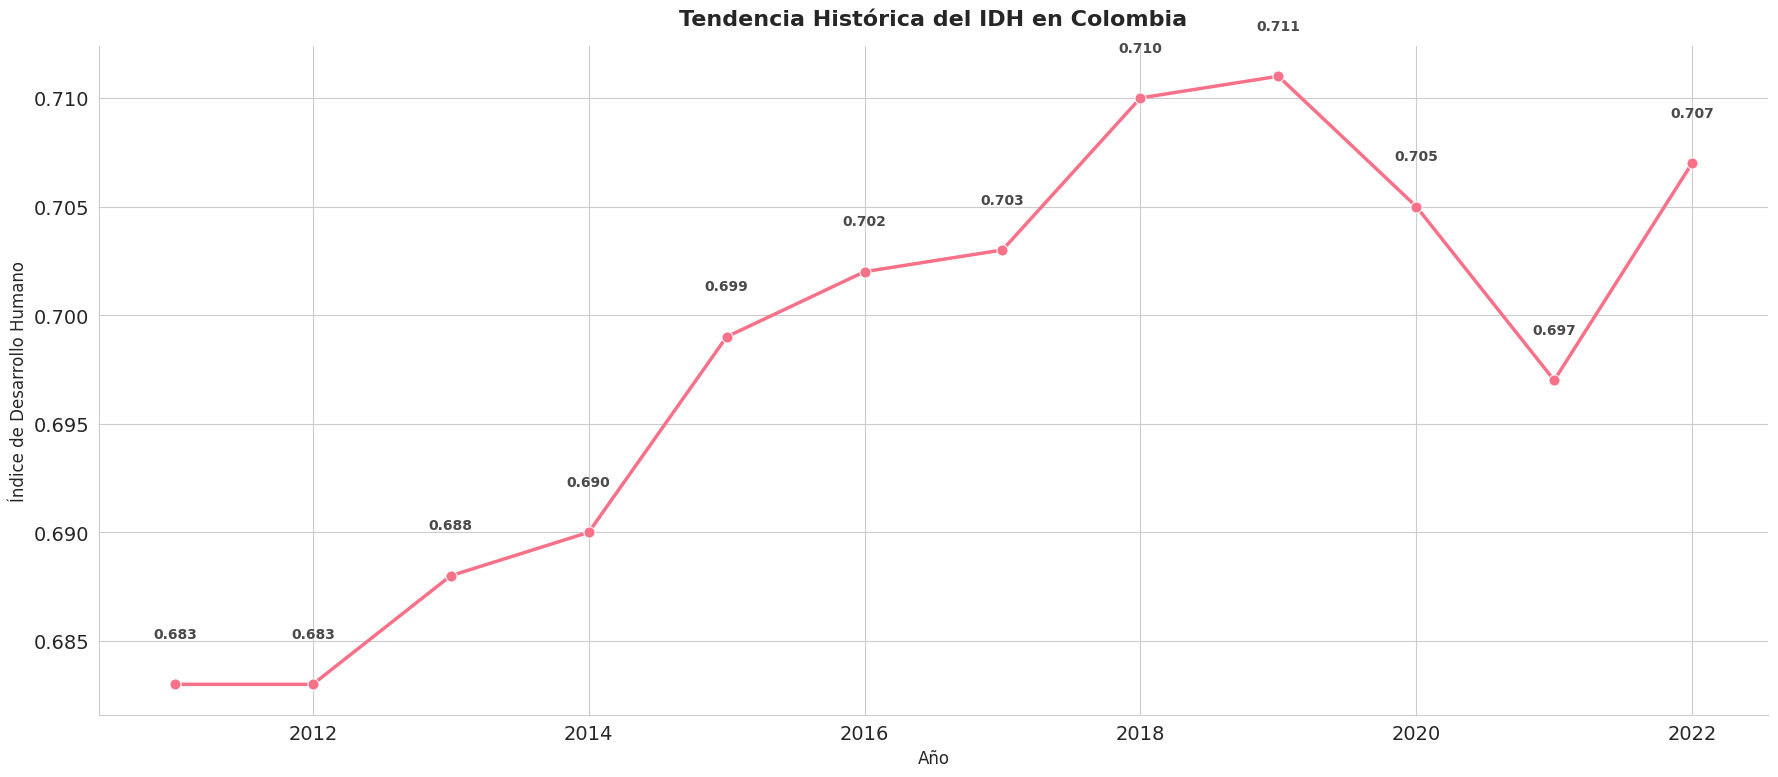

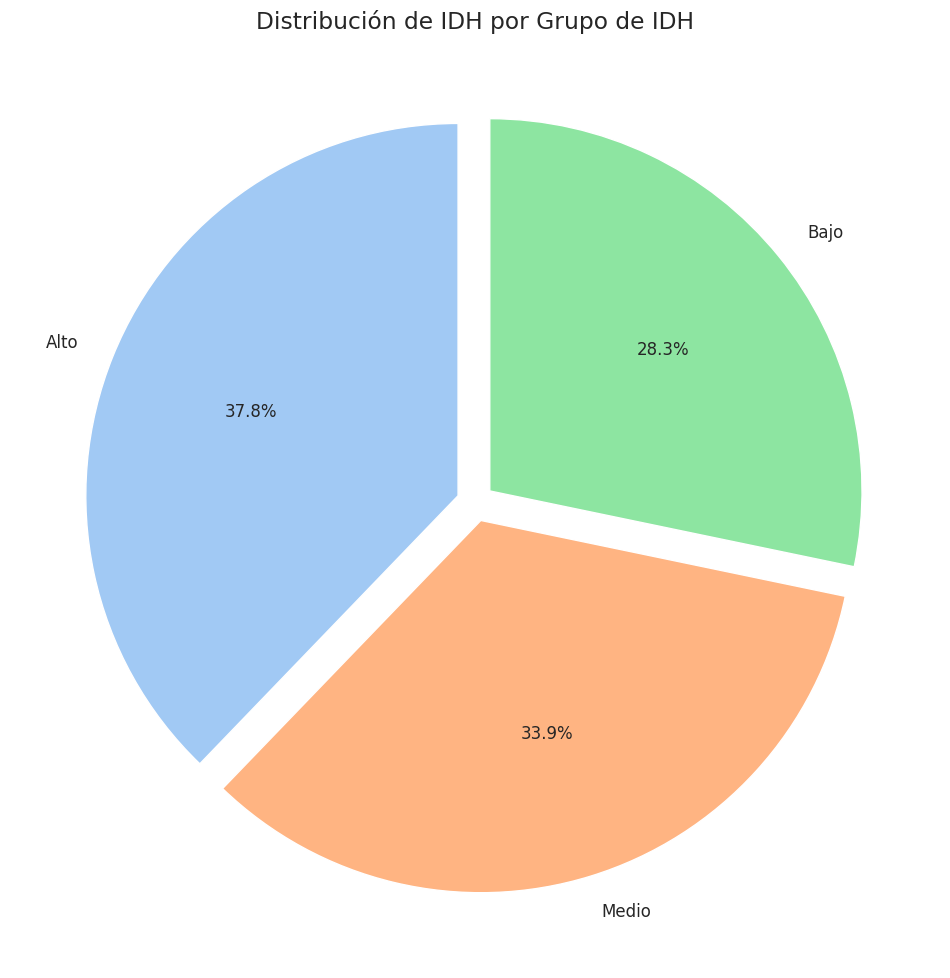

/tmp/ipykernel_2262/2673056020.py:111: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


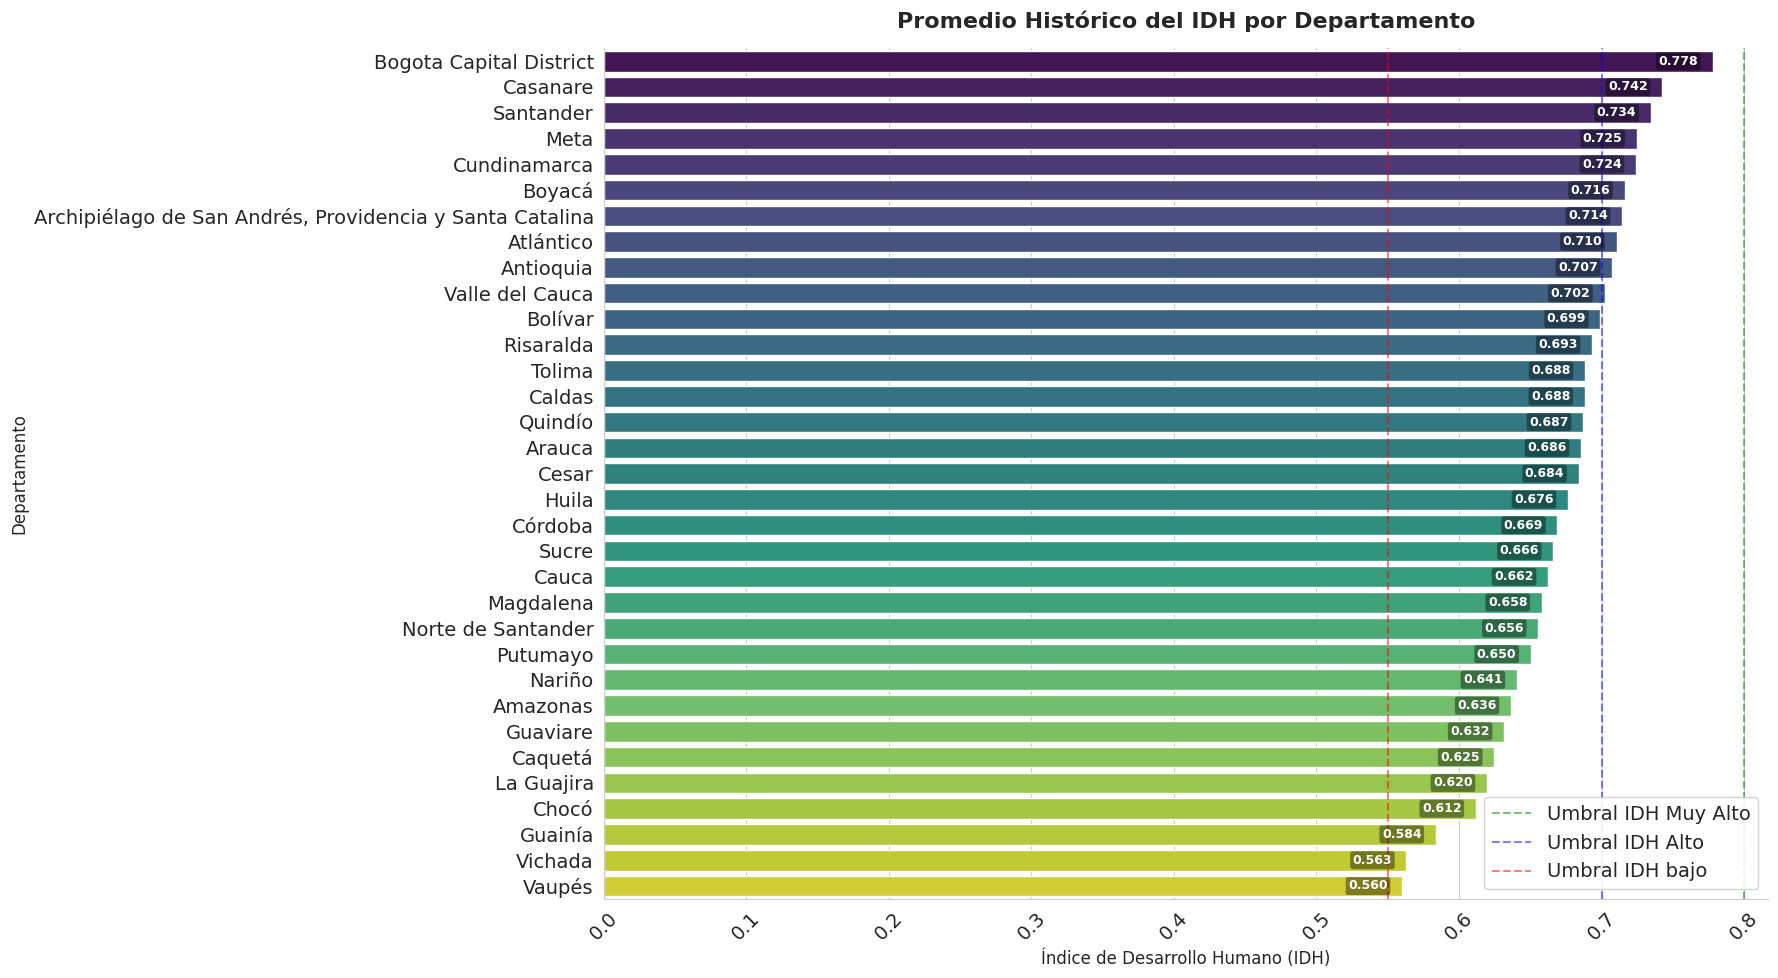

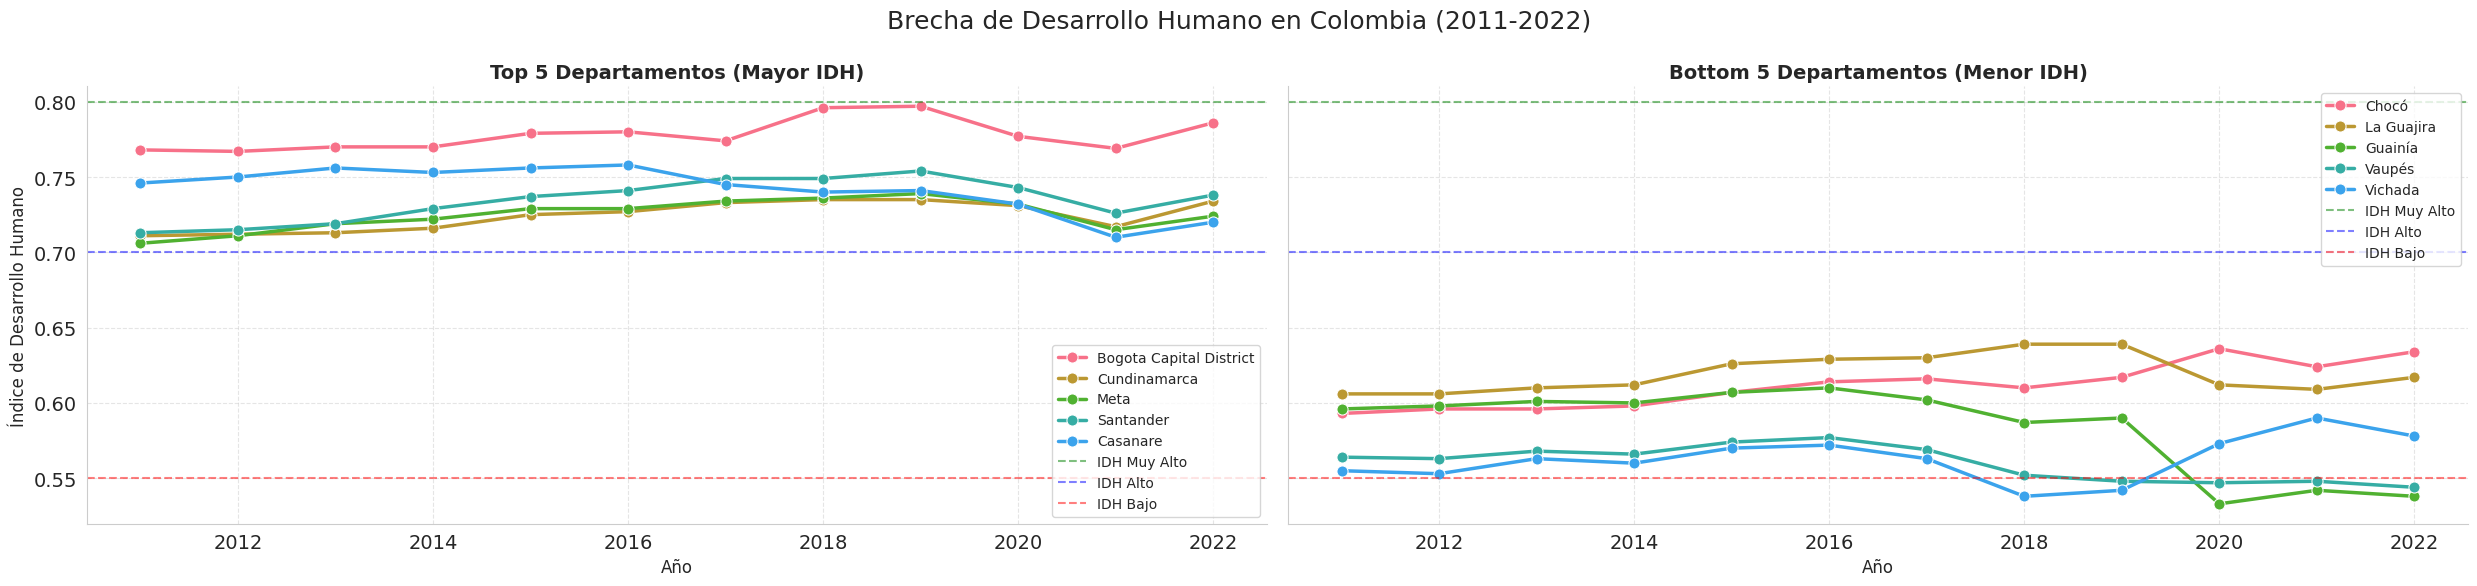

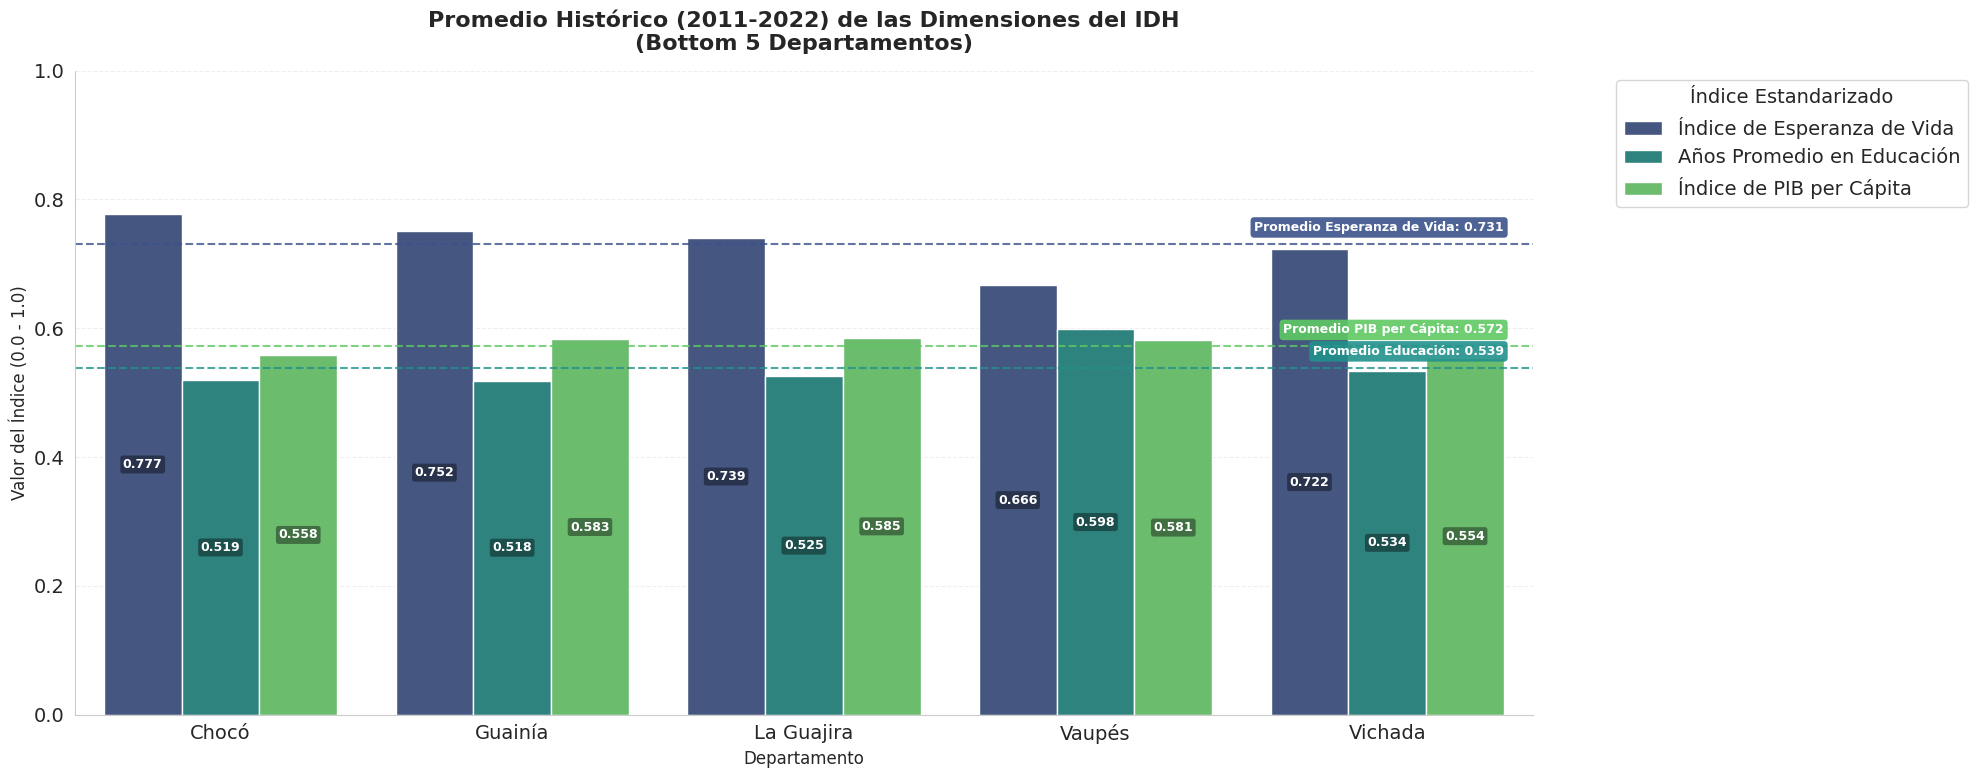

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aumentar el tamaño de fuente global para las gráficas
plt.rcParams['font.size'] = 14

print('Proceso de preparacion de datos - Informe descriptivo de IDH')
print("")
print(idh_df.describe()) # Descriptive statistics for IDH data

# Suma total de los valores de IDH (proxy para "ventas totales")
print("\n- Suma Total de Índices de Desarrollo Humano")
total_idh_sum = idh_df['índice_de_desarrollo_humano'].sum()
print(f"\n- La suma total de los valores de IDH es: {total_idh_sum:,.2f}")

# Promedio de IDH (proxy para "promedio de ventas")
print("\n- Promedio de Índice de Desarrollo Humano")
average_idh = idh_df['índice_de_desarrollo_humano'].mean()
print(f"\n- El promedio de IDH es: {average_idh:,.2f}")

# Departamento con el mayor IDH (proxy para "producto con mas precio")
print("\n- Departamento con el mayor Índice de Desarrollo Humano")
max_idh_department = idh_df.loc[idh_df['índice_de_desarrollo_humano'].idxmax()]
print(f"\n- El departamento con el IDH más alto es: {max_idh_department['departamento']} con un IDH de {max_idh_department['índice_de_desarrollo_humano']:.3f} en el año {int(max_idh_department['año'])}")

# Datos para mis graficas

# IDH promedio por Grupo de IDH (proxy para "ventas por categorias")
print("\nReporte IDH promedio por Grupo de IDH")
idhByGroup = idh_df.groupby('grupo_de_idh')['índice_de_desarrollo_humano'].mean().sort_values(ascending=False)
print(f"{idhByGroup}")

# IDH promedio por Departamento (proxy para "ventas por ciudad")
print("\nReporte IDH promedio por Departamento")
idhByDepartment = idh_df.groupby('departamento')['índice_de_desarrollo_humano'].mean().sort_values(ascending=False)
print(f"{idhByDepartment}")

# IDH promedio por Departamento (otra vista - proxy para "ventas por producto")
print("\nReporte IDH promedio por Departamento (detallado)")
idhByDepartmentDetailed = idh_df.groupby('departamento')['índice_de_desarrollo_humano'].mean().sort_values(ascending=False)
print(f"{idhByDepartmentDetailed}")


#----------------------------
# Graficas
#----------------------------

# Gráfica lineal de IDH promedio por Año para Colombia (proxy para "ventas por fecha")
print("\nGráfica lineal de IDH promedio por Año")
col_idh_df = idh_df[idh_df['departamento'] == 'Colombia']
print(col_idh_df.head())
print(col_idh_df.info())

plt.figure(figsize=(18, 8)) # Aumentar un poco el tamaño de la figura

ax = sns.lineplot(
    data=col_idh_df,
    x="año",
    y="índice_de_desarrollo_humano",
    marker="o",
    linewidth=2.5, # Engrosamos la línea para darle jerarquía
    markersize=8   # Hacemos los puntos un poco más grandes para que destaquen
)

for x, y in zip(col_idh_df['año'], col_idh_df['índice_de_desarrollo_humano']):
    plt.text(
        x = x,
        y = y + 0.002,      # Sumamos un pequeño margen a 'y' para que el texto no tape el punto
        s = f'{y:.3f}',     # Formateamos el texto para mostrar exactamente 3 decimales (estándar del IDH)
        ha = 'center',      # Centramos el texto horizontalmente sobre el punto
        va = 'bottom',      # Alineamos desde la base del texto
        fontsize = 10,
        fontweight = 'bold',
        color = '#4A4A4A'   # Usamos un gris oscuro (más profesional y menos agresivo que el negro puro)
    )

plt.title("Tendencia Histórica del IDH en Colombia", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Índice de Desarrollo Humano", fontsize=12)
plt.xticks(rotation=0)

sns.despine()

plt.tight_layout()
plt.show()

# Gráfica de torta de IDH por Grupo de IDH (proxy para "ventas por categorias")
fig, ax =plt.subplots(figsize=(12, 10)) # Aumentar un poco el tamaño de la figura
colors = sns.color_palette('pastel',len(idhByGroup))
wedges, texts, autotexts = ax.pie(
    idhByGroup.values,
    labels=idhByGroup.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.05] * len(idhByGroup),
    textprops={'fontsize': 12} # Asegurar que el texto dentro del pastel también sea más grande

)
ax.set_title("Distribución de IDH por Grupo de IDH")
plt.tight_layout()
plt.show()

# Grafico de barras del promedio de idh por departamento
dep_idh_df = idh_df[idh_df['departamento'] != 'Colombia']
dep_idhMean = dep_idh_df.groupby('departamento')['índice_de_desarrollo_humano'].mean().reset_index()
dep_idhMean = dep_idhMean.sort_values(by='índice_de_desarrollo_humano', ascending=False)

plt.figure(figsize=(18, 10)) # Aumentar un poco el tamaño de la figura

ax = sns.barplot(
    data=dep_idhMean,
    x='índice_de_desarrollo_humano',
    y='departamento',
    palette="viridis"
)

for p in ax.patches:
    width = p.get_width() # Obtiene la longitud exacta de la barra (el valor del IDH)

    if width > 0:
        ax.text(
            x = width - 0.01, # Lo posicionamos ligeramente a la izquierda del borde derecho
            y = p.get_y() + (p.get_height() / 2), # Lo centramos verticalmente en la barra
            s = f'{width:.3f}', # Formato estándar de 3 decimales
            ha = 'right',       # Alineación a la derecha
            va = 'center',      # Alineación al centro
            color = 'white',
            fontweight = 'bold',
            fontsize = 9,
            # Aquí creamos el cuadro oscuro translúcido para asegurar contraste
            bbox = dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2')
        )

plt.title("Promedio Histórico del IDH por Departamento", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Índice de Desarrollo Humano (IDH)", fontsize=12)
plt.ylabel("Departamento", fontsize=12)

plt.xticks(rotation=45)
plt.axvline(x=0.800, color='green', linestyle='--', alpha=0.5, label='Umbral IDH Muy Alto')
plt.axvline(x=0.700, color='blue', linestyle='--', alpha=0.5, label='Umbral IDH Alto')
plt.axvline(x=0.550, color='red', linestyle='--', alpha=0.5, label='Umbral IDH bajo')

sns.despine() # Quita el marco superior y derecho
plt.legend(loc='lower right', framealpha=0.9) # Movemos la leyenda abajo para no tapar las primeras barras

plt.tight_layout()
plt.show()

# Grafico timeline idh top 5 vs bottom 5 (departamentos)
top5 = dep_idhMean['departamento'].head(5).tolist()
bottom5 = dep_idhMean['departamento'].tail(5).tolist()
depIdh_df_top5 = idh_df[idh_df['departamento'].isin(top5)]
depIdh_df_bottom5 = idh_df[idh_df['departamento'].isin(bottom5)]

fig, axes = plt.subplots(1, 2, figsize=(25, 6), sharey=True)

#top 5 chart
sns.lineplot(
    data=depIdh_df_top5,
    x="año",
    y="índice_de_desarrollo_humano",
    hue="departamento",
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=axes[0]
)

axes[0].set_title("Top 5 Departamentos (Mayor IDH)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Año", fontsize=12)
axes[0].set_ylabel("Índice de Desarrollo Humano", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)

#bottom 5 chart
sns.lineplot(
    data=depIdh_df_bottom5,
    x="año",
    y="índice_de_desarrollo_humano",
    hue="departamento",
    marker='o',
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)

axes[1].set_title("Bottom 5 Departamentos (Menor IDH)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Año", fontsize=12)
axes[1].set_ylabel("")
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[0].axhline(y=0.800, color='green', linestyle='--', alpha=0.5, label='IDH Muy Alto')
axes[0].axhline(y=0.700, color='blue', linestyle='--', alpha=0.5, label='IDH Alto')
axes[0].axhline(y=0.550, color='red', linestyle='--', alpha=0.5, label='IDH Bajo')
axes[0].legend(loc='lower right', fontsize=10)

axes[1].axhline(y=0.800, color='green', linestyle='--', alpha=0.5, label='IDH Muy Alto')
axes[1].axhline(y=0.700, color='blue', linestyle='--', alpha=0.5, label='IDH Alto')
axes[1].axhline(y=0.550, color='red', linestyle='--', alpha=0.5, label='IDH Bajo')
axes[1].legend(loc='upper right', fontsize=10)

sns.despine()

plt.suptitle("Brecha de Desarrollo Humano en Colombia (2011-2022)", fontsize=18)
plt.tight_layout()
plt.show()

# Arreglo graficas de las dimensiones para regiones rezagadas
nombres_limpios = {
    'indice_estandarizado_de_esperanza_de_vida': 'Índice de Esperanza de Vida',
    'años_promedio_de_educación_estandarizados': 'Años Promedio en Educación',
    'índice_estandarizado_de_pib_per_cápita_minero_ppa': 'Índice de PIB per Cápita'
}

dim_cols = list(nombres_limpios.keys())
dimMean_b5 = depIdh_df_bottom5.groupby('departamento')[dim_cols].mean().reset_index()

dimMean_b5.rename(columns=nombres_limpios, inplace=True)
nuevas_cols = list(nombres_limpios.values())

colores_viridis = sns.color_palette("viridis", n_colors=3)

melt_dimMean_b5 = pd.melt(
    dimMean_b5,
    id_vars=['departamento'],
    value_vars=nuevas_cols,
    var_name='dimension',
    value_name='Promedio')

plt.figure(figsize=(20, 8))
ax = sns.barplot(
    data=melt_dimMean_b5,
    x='departamento',
    y='Promedio',
    hue='dimension',
    palette=colores_viridis
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x = p.get_x() + (p.get_width() / 2),
            y = height / 2,
            s = f'{height:.3f}',
            ha = 'center',
            va = 'center',
            color = 'white',
            fontweight = 'bold',
            fontsize = 9,
            bbox = dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2')
        )

promedios = {
    'Esperanza de Vida': dimMean_b5['Índice de Esperanza de Vida'].mean(),
    'Educación': dimMean_b5['Años Promedio en Educación'].mean(),
    'PIB per Cápita': dimMean_b5['Índice de PIB per Cápita'].mean()
}

x_etiqueta = ax.get_xlim()[1] - 0.1

for i, (nombre, valor) in enumerate(promedios.items()):
    ax.axhline(y=valor, color=colores_viridis[i], linestyle='--', alpha=0.8)

    ax.text(
        x = x_etiqueta,
        y = valor + 0.015,
        s = f'Promedio {nombre}: {valor:.3f}',
        ha = 'right',
        va = 'bottom',
        color = 'white',
        fontweight = 'bold',
        fontsize = 9,
        bbox = dict(facecolor=colores_viridis[i], alpha=0.9, edgecolor='none', boxstyle='round,pad=0.3')
    )

plt.ylim(0, 1.0)
plt.title("Promedio Histórico (2011-2022) de las Dimensiones del IDH\n(Bottom 5 Departamentos)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Departamento", fontsize=12)
plt.ylabel("Valor del Índice (0.0 - 1.0)", fontsize=12)

plt.legend(title="Índice Estandarizado", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Exploracion de datos de matriculacion y desercion

Proceso de preparacion de datos - Informe descriptivo de matriculacion y desercion para los departamentos mas afectados

               año  código_departamento  población_5_16  \
count   396.000000           396.000000    3.960000e+02   
mean   2016.500000            52.151515    3.024727e+05   
std       3.456419            30.829663    3.138346e+05   
min    2011.000000             5.000000    1.079600e+04   
25%    2013.750000            20.000000    8.785650e+04   
50%    2016.500000            52.000000    2.362655e+05   
75%    2019.250000            81.000000    3.892458e+05   
max    2022.000000            99.000000    1.479334e+06   

       tasa_matriculación_5_16  cobertura_neta  cobertura_neta_transición  \
count               396.000000      396.000000                 396.000000   
mean                  0.853741        0.857610                   0.569277   
std                   0.105015        0.105844                   0.116768   
min                   0.523300        0

/tmp/ipykernel_7122/339002615.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


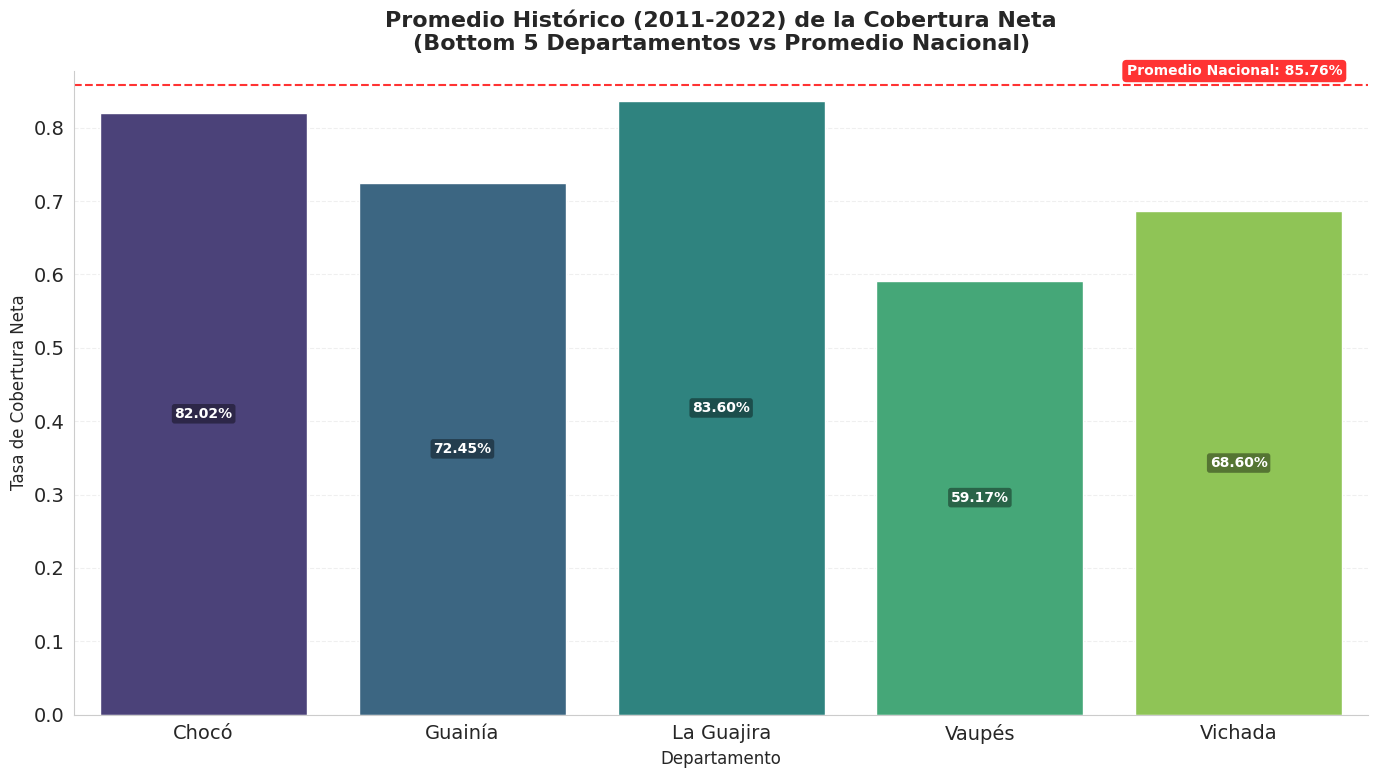

/tmp/ipykernel_7122/339002615.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


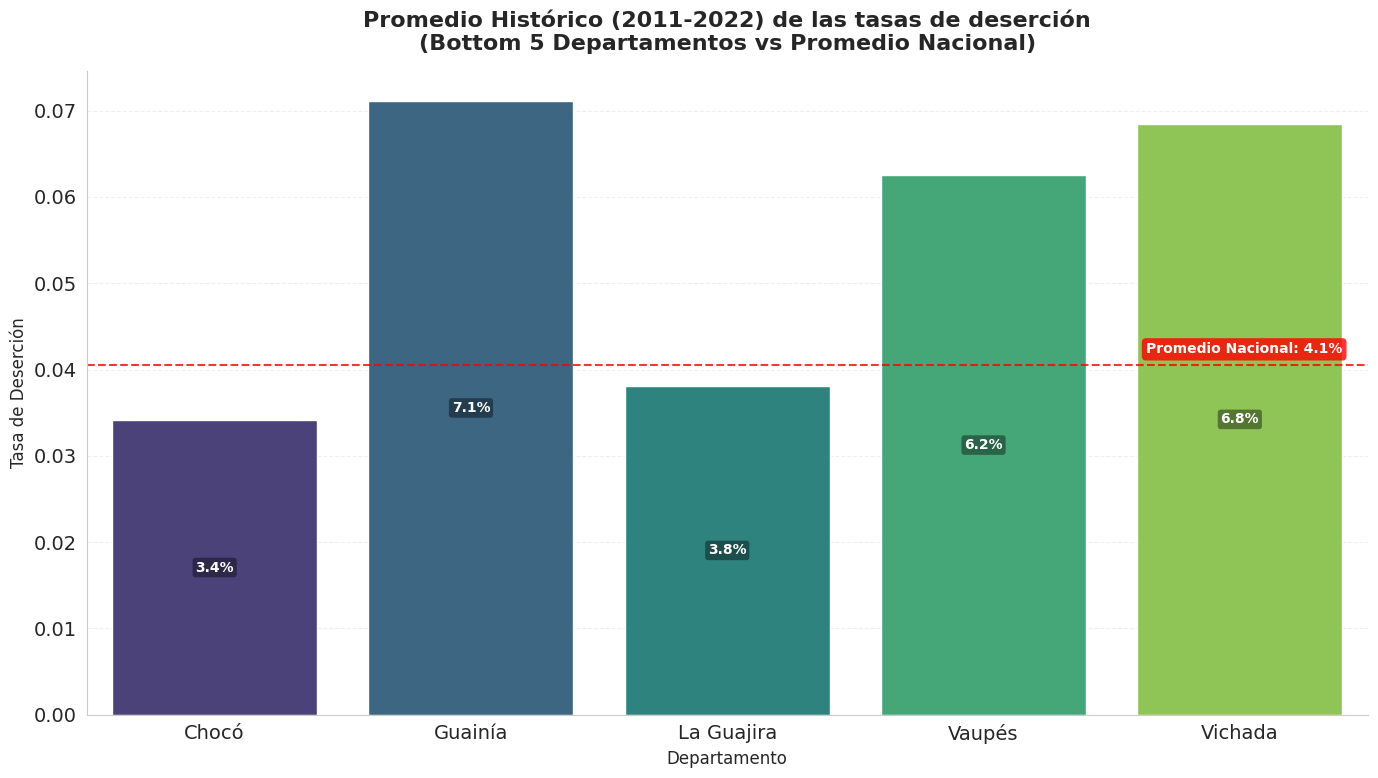

la diferencia de matriculacion regional y nacional es de : -0.13
hay una diferencia relativa de: -14.68
la diferencia de desercion regional ynacional es de : 0.01
hay una diferencia relativa de: 35.33


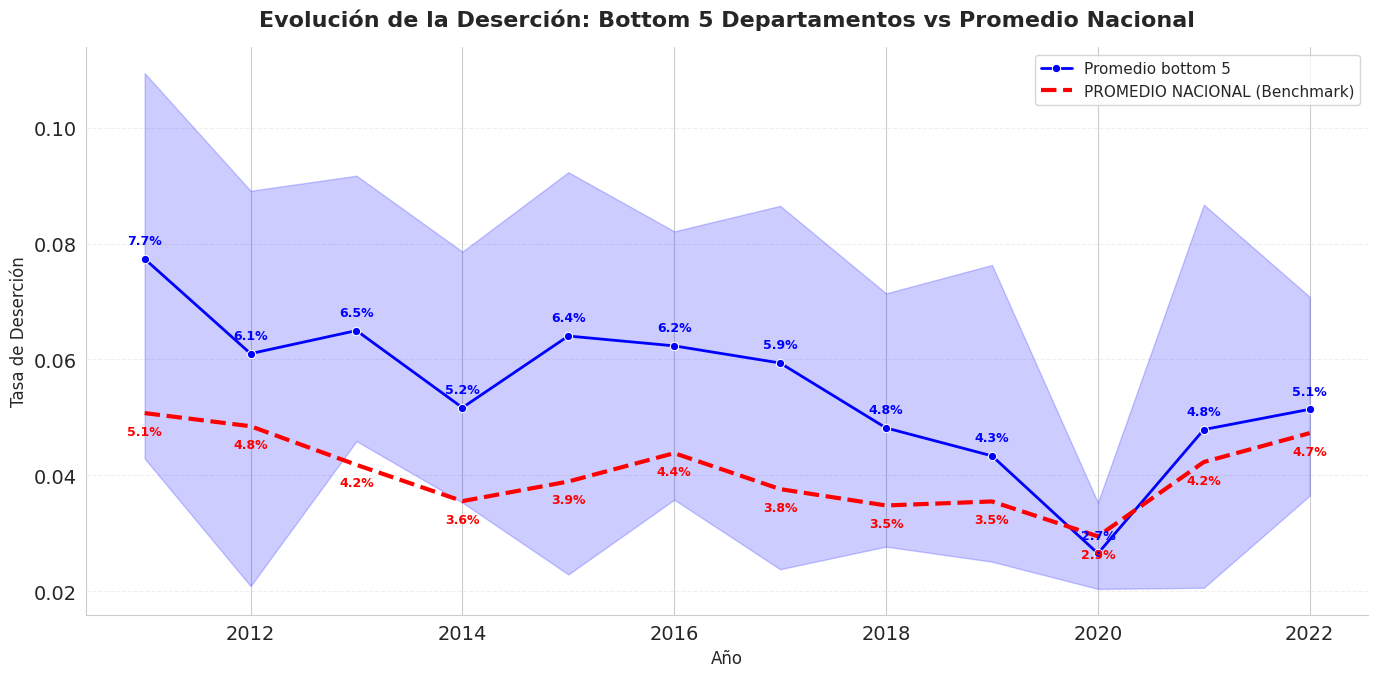

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aumentar el tamaño de fuente global para las gráficas
plt.rcParams['font.size'] = 14

print('Proceso de preparacion de datos - Informe descriptivo de matriculacion y desercion para los departamentos mas afectados')
print("")
print(matricula_departamento_df.describe()) # Descriptive statistics for IDH data

# Promedio de cobertura de matriculacion (proxy para "promedio de ventas")
print("\n- Promedio de cobertura de matriculacion")
average_matriculacion = matricula_departamento_df['cobertura_neta'].mean()
print(f"\n- El promedio de matriculacion a nivel nacional es: {average_matriculacion:,.2f}")

# Departamento con la mayor cobertura de matricualcion (proxy para "producto con mas precio")
print("\n- Departamento con la mayor cobertura de matricualcion")
max_matriculacion_department = matricula_departamento_df.loc[matricula_departamento_df['cobertura_neta'].idxmax()]
print(f"\n- El departamento con la mayor cobertura de matriculacion es: {max_matriculacion_department['departamento']} con un IDH de {max_matriculacion_department['cobertura_neta']:.3f} en el año {int(max_idh_department['año'])}")

# Promedio de desercion (proxy para "promedio de ventas")
print("\n- Promedio de desercion")
average_desercion = matricula_departamento_df['deserción'].mean()
print(f"\n- El promedio de desercion a nivel nacional es: {average_desercion:,.2f}")

# Departamento con la mayor desercion (proxy para "producto con mas precio")
print("\n- Departamento con la mayor desercion")
max_desercion_department = matricula_departamento_df.loc[matricula_departamento_df['deserción'].idxmax()]
print(f"\n- El departamento con la mayor desercion es: {max_desercion_department['departamento']} con un IDH de {max_desercion_department['deserción']:.3f} en el año {int(max_idh_department['año'])}")

#----------------------------
# Datos para mis graficas
#----------------------------

# matriculacion promedio por Departamento (proxy para "ventas por ciudad")
print("\nReporte matriculacion promedio por Departamento")
matriculacionByDepartment = matricula_departamento_df.groupby('departamento')['cobertura_neta'].mean().sort_values(ascending=False)
print(f"{matriculacionByDepartment}")

# desercion promedio por Departamento (proxy para "ventas por ciudad")
print("\nReporte desercion promedio por Departamento")
desercionByDepartment = matricula_departamento_df.groupby('departamento')['deserción'].mean().sort_values(ascending=False)
print(f"{desercionByDepartment}")


#----------------------------
# Graficas
#----------------------------

# graficas de la proporcion de matriculacion para bottom 5
#grafico para tasa de matriculacion
codedane_b5 = (27, 44, 94, 97, 99)
matricula_departamento_df_b5 = matricula_departamento_df[matricula_departamento_df['código_departamento'].isin(codedane_b5)]
matricula_departamento_df_b5_matriculacion = matricula_departamento_df_b5.groupby('departamento')['cobertura_neta'].mean().reset_index()

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=matricula_departamento_df_b5_matriculacion,
    x='departamento',
    y='cobertura_neta',
    palette="viridis"
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x = p.get_x() + (p.get_width() / 2),
            y = height / 2,
            s = f'{height:.2%}',
            ha = 'center',
            va = 'center',
            color = 'white',
            fontweight = 'bold',
            fontsize = 10,
            bbox = dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2')
        )

ax.axhline(y=average_matriculacion, color='red', linestyle='--', alpha=0.8)

ax.text(
    x = ax.get_xlim()[1] - 0.1,
    y = average_matriculacion + 0.01,
    s = f'Promedio Nacional: {average_matriculacion:.2%}',
    ha = 'right',
    va = 'bottom',
    color = 'white',
    fontweight = 'bold',
    fontsize = 10,
    bbox = dict(facecolor='red', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')
)

plt.title("Promedio Histórico (2011-2022) de la Cobertura Neta\n(Bottom 5 Departamentos vs Promedio Nacional)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Departamento", fontsize=12)
plt.ylabel("Tasa de Cobertura Neta", fontsize=12)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#grafico para tasa de desercion
matricula_departamento_df_b5_desercion = matricula_departamento_df_b5.groupby('departamento')['deserción'].mean().reset_index()

plt.figure(figsize=(14, 8))

ax = sns.barplot(
    data=matricula_departamento_df_b5_desercion,
    x='departamento',
    y='deserción',
    palette="viridis"
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            x = p.get_x() + (p.get_width() / 2),
            y = height / 2,
            s = f'{height:.1%}', # Formato porcentaje (ej: 0.05 -> 5.0%)
            ha = 'center',
            va = 'center',
            color = 'white',
            fontweight = 'bold',
            fontsize = 10,
            bbox = dict(facecolor='black', alpha=0.4, edgecolor='none', boxstyle='round,pad=0.2')
        )

ax.axhline(y=average_desercion, color='red', linestyle='--', alpha=0.8)

ax.text(
    x = ax.get_xlim()[1] - 0.1,
    y = average_desercion + 0.001, # Ajuste fino según la escala de deserción
    s = f'Promedio Nacional: {average_desercion:.1%}',
    ha = 'right',
    va = 'bottom',
    color = 'white',
    fontweight = 'bold',
    fontsize = 10,
    bbox = dict(facecolor='red', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.3')
)

plt.title("Promedio Histórico (2011-2022) de las tasas de deserción\n(Bottom 5 Departamentos vs Promedio Nacional)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Departamento", fontsize=12)
plt.ylabel("Tasa de Deserción", fontsize=12)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#promedios nacionales vs promedios regionales
average_matricula_departamento_df_b5_matriculacion = matricula_departamento_df_b5_matriculacion['cobertura_neta'].mean()
average_matricula_departamento_df_b5_desercion = matricula_departamento_df_b5_desercion['deserción'].mean()
matriculacion_delta = average_matricula_departamento_df_b5_matriculacion - average_matriculacion
desercion_delta = average_matricula_departamento_df_b5_desercion - average_desercion
matriculacion_relativa = (matriculacion_delta / average_matriculacion) * 100
desercion_relativa = (desercion_delta / average_desercion) * 100


print(f'la diferencia de matriculacion regional y nacional es de : {matriculacion_delta:.2f}')
print(f'hay una diferencia relativa de: {matriculacion_relativa:.2f}')
print(f'la diferencia de desercion regional ynacional es de : {desercion_delta:.2f}')
print(f'hay una diferencia relativa de: {desercion_relativa:.2f}')

# Desercion historica
tendencia_nacional_desercion = matricula_departamento_df.groupby('año')['deserción'].mean().reset_index()
tendencia_b5_desercion = matricula_departamento_df_b5.groupby('año')['deserción'].mean().reset_index()

# promedio regional linea
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=matricula_departamento_df_b5,
    x='año',
    y='deserción',
    marker='o',
    linewidth=2,
    color='blue',
    errorbar=('pi', 100),
    label='Promedio bottom 5',
    ax=plt.gca()
)

# promedio nacional linea
sns.lineplot(
    data=tendencia_nacional_desercion,
    x='año',
    y='deserción',
    color='red',
    linestyle='--',
    linewidth=3,
    label='PROMEDIO NACIONAL (Benchmark)'
)

for x, y in zip(tendencia_b5_desercion['año'], tendencia_b5_desercion['deserción']):
    plt.text(x, y + 0.002, f'{y:.1%}', color='blue', fontsize=9, fontweight='bold', ha='center', va='bottom')

for x, y in zip(tendencia_nacional_desercion['año'], tendencia_nacional_desercion['deserción']):
    plt.text(x, y - 0.002, f'{y:.1%}', color='red', fontsize=9, fontweight='bold', ha='center', va='top')

plt.title("Evolución de la Deserción: Bottom 5 Departamentos vs Promedio Nacional",
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Tasa de Deserción", fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()


Exploracion de datos matriculacion datos micro

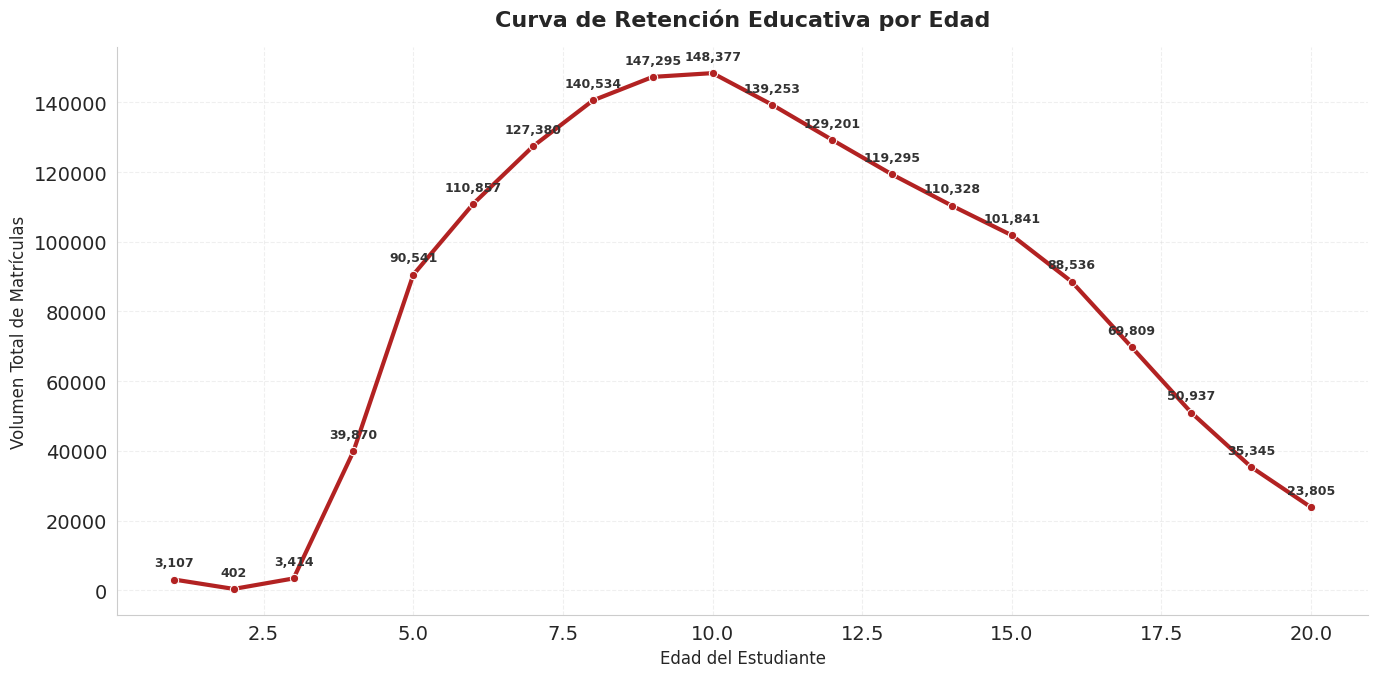

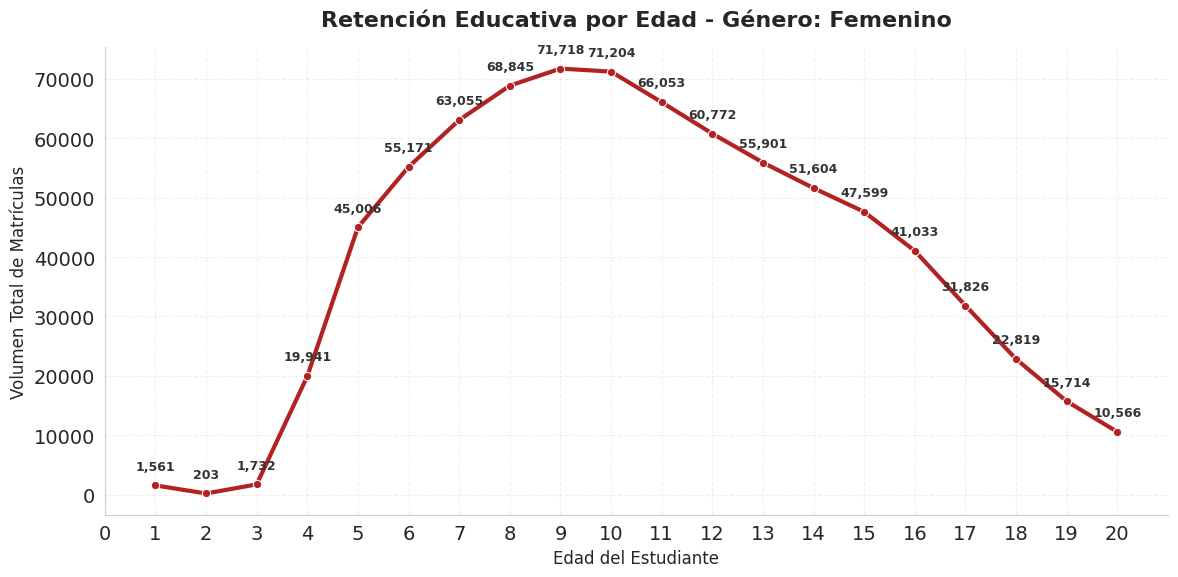

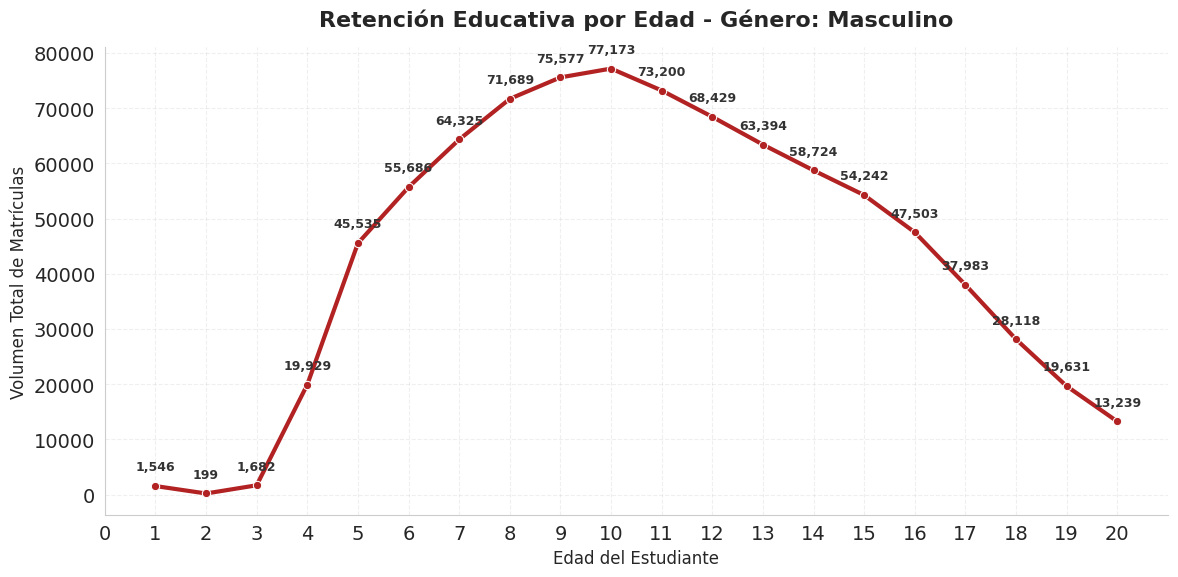

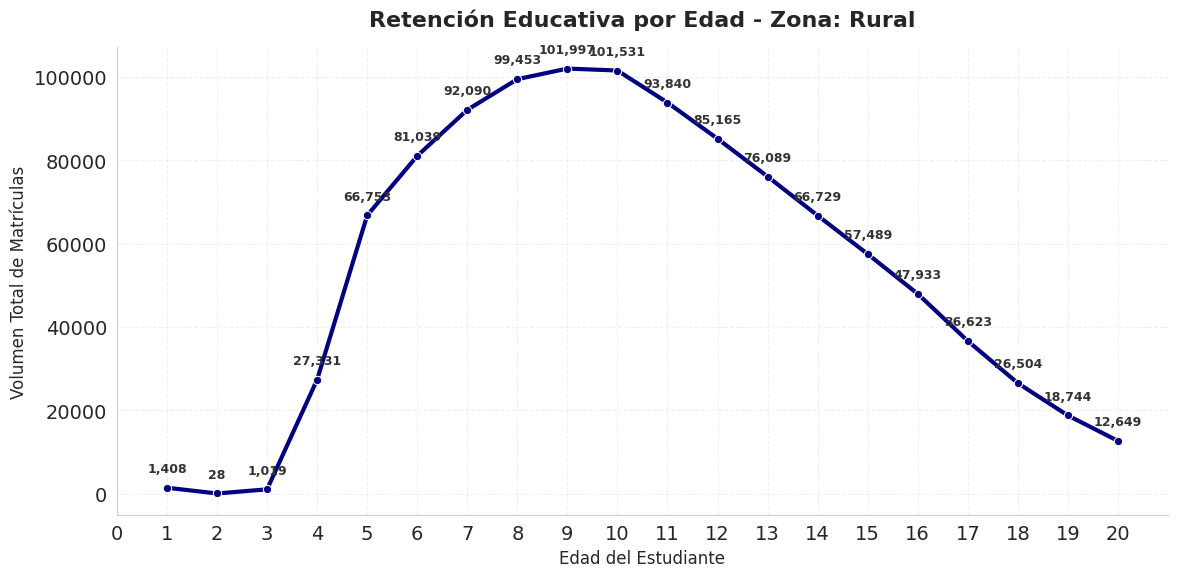

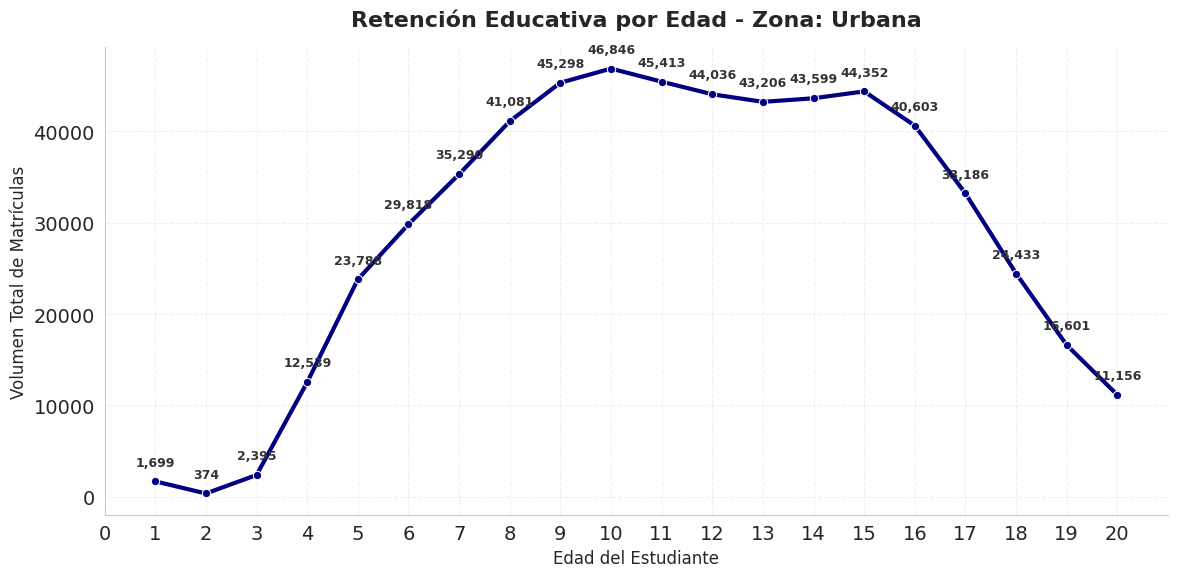

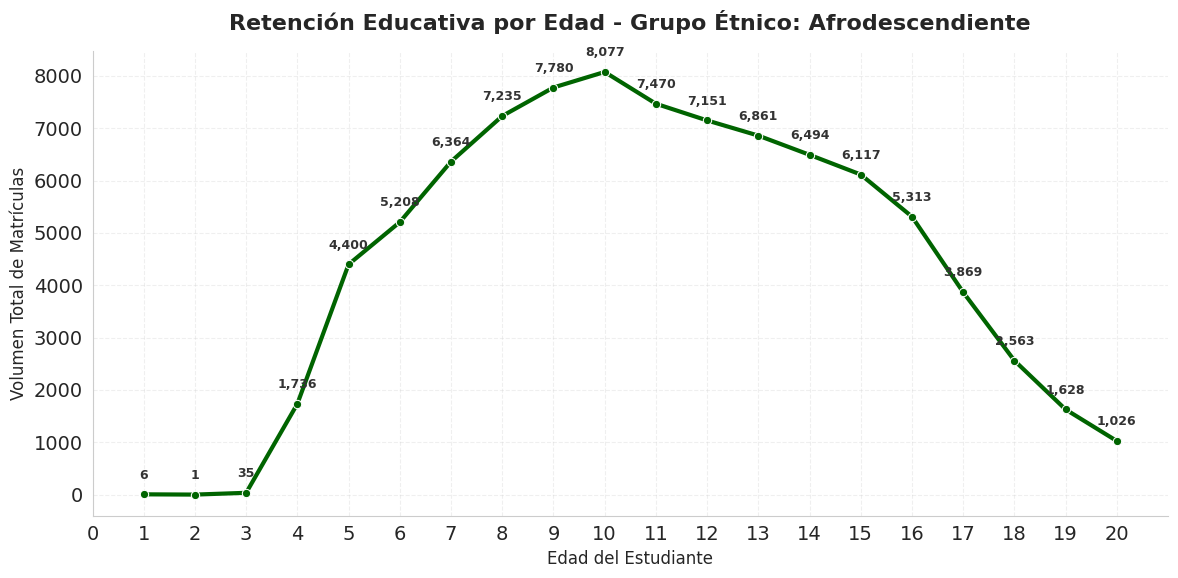

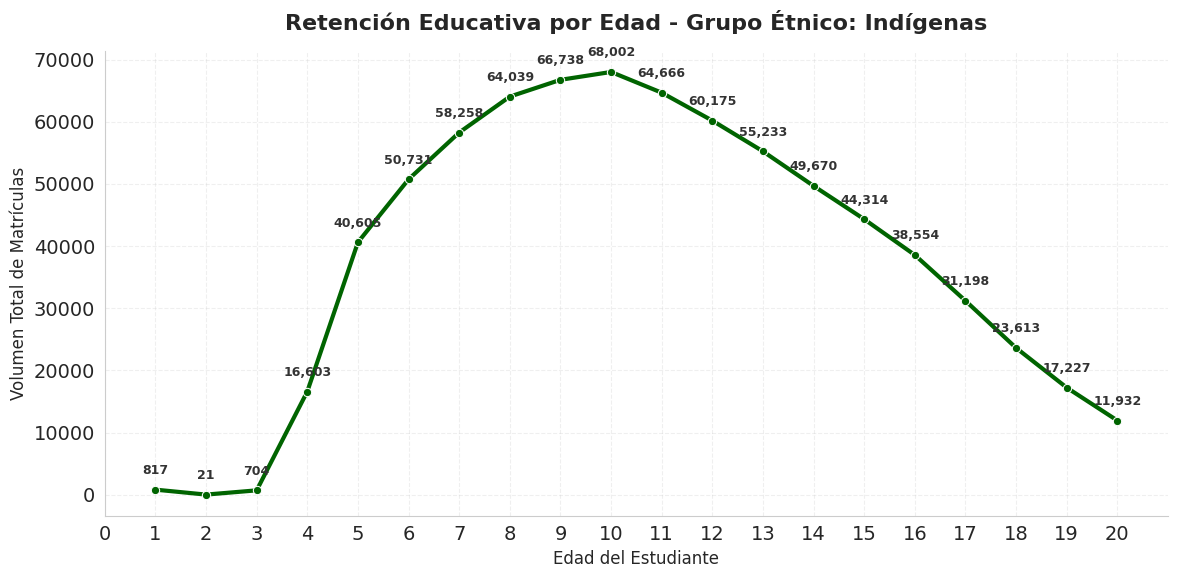

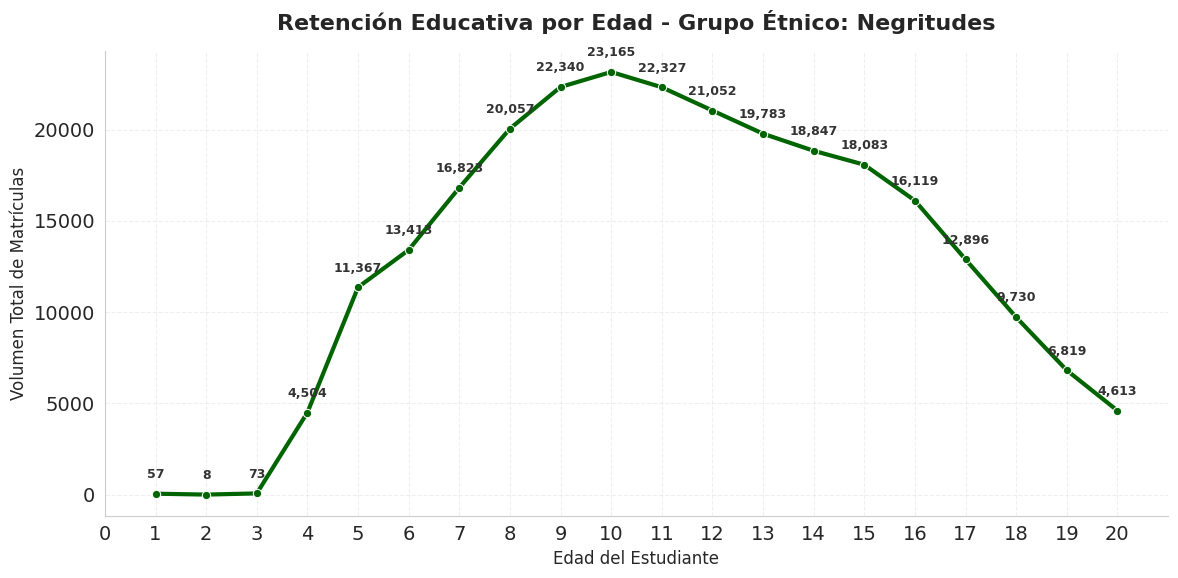

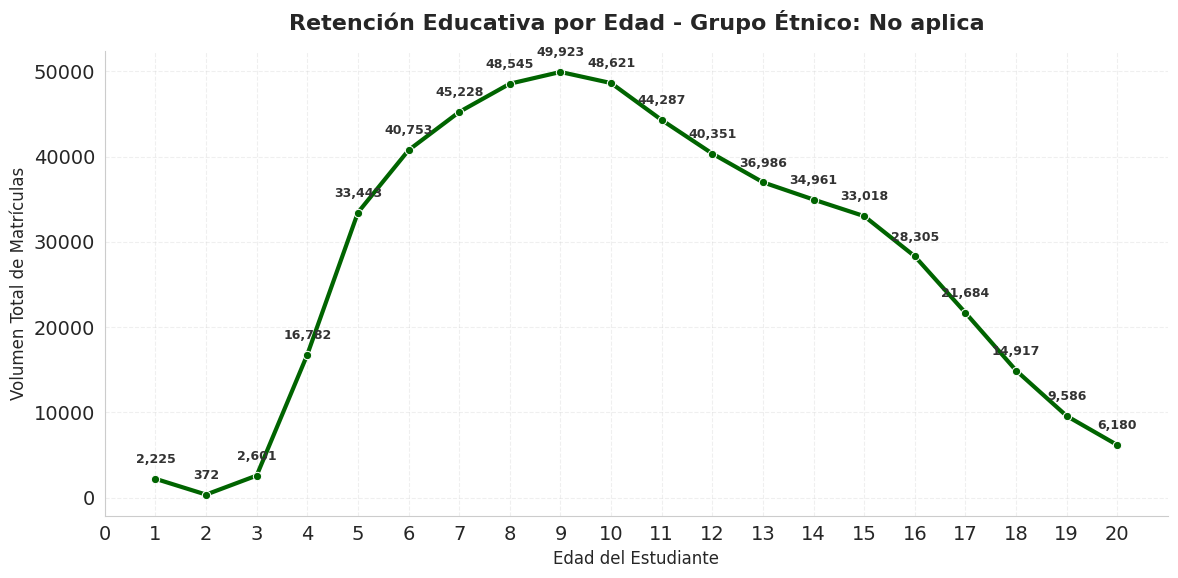

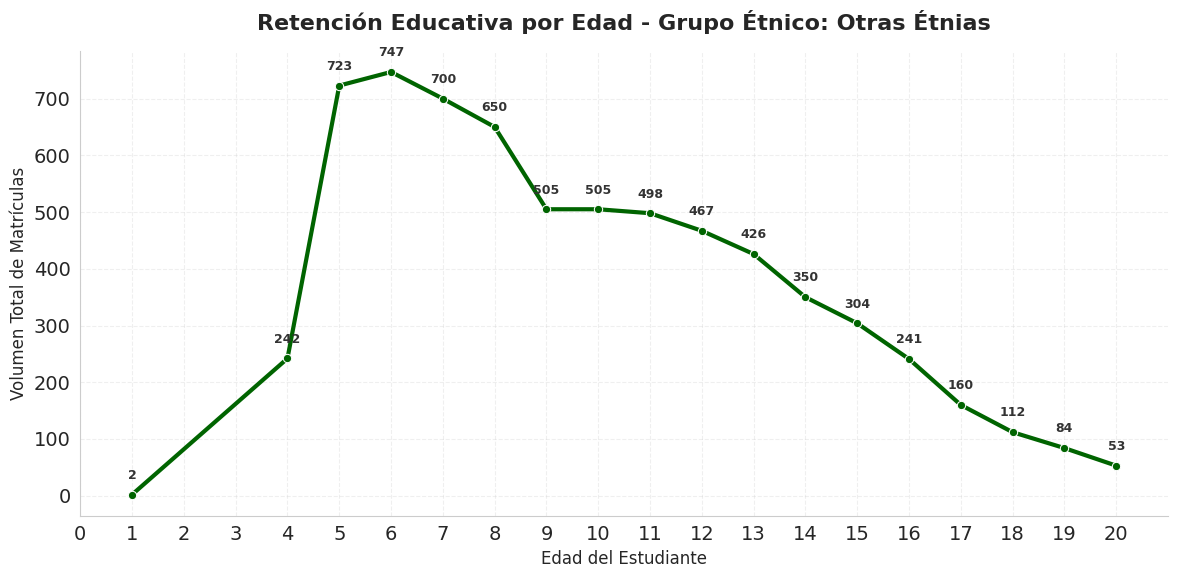

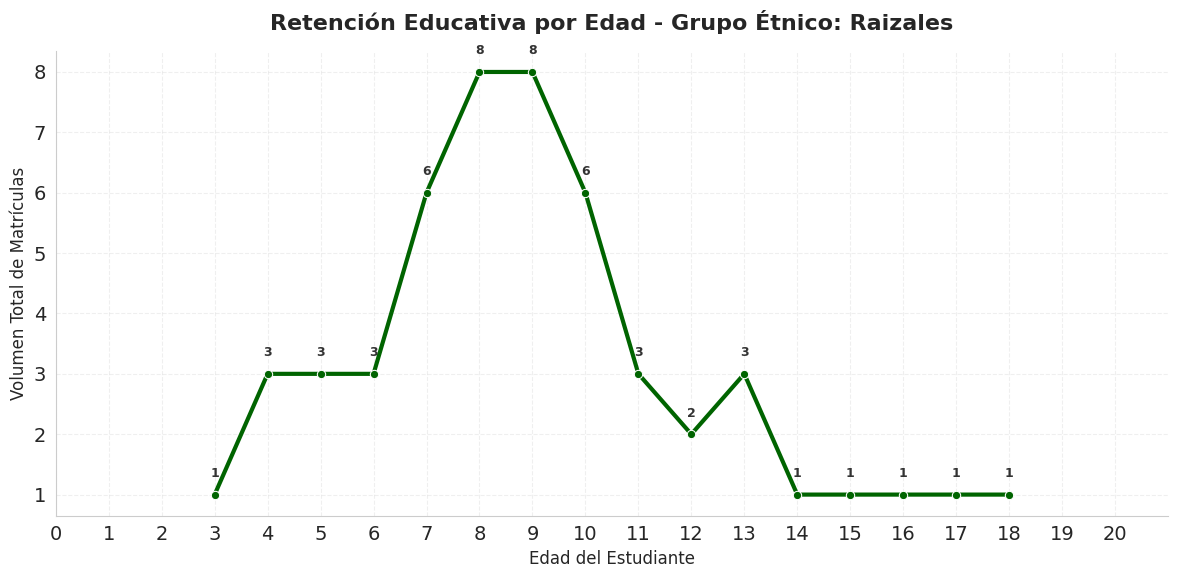

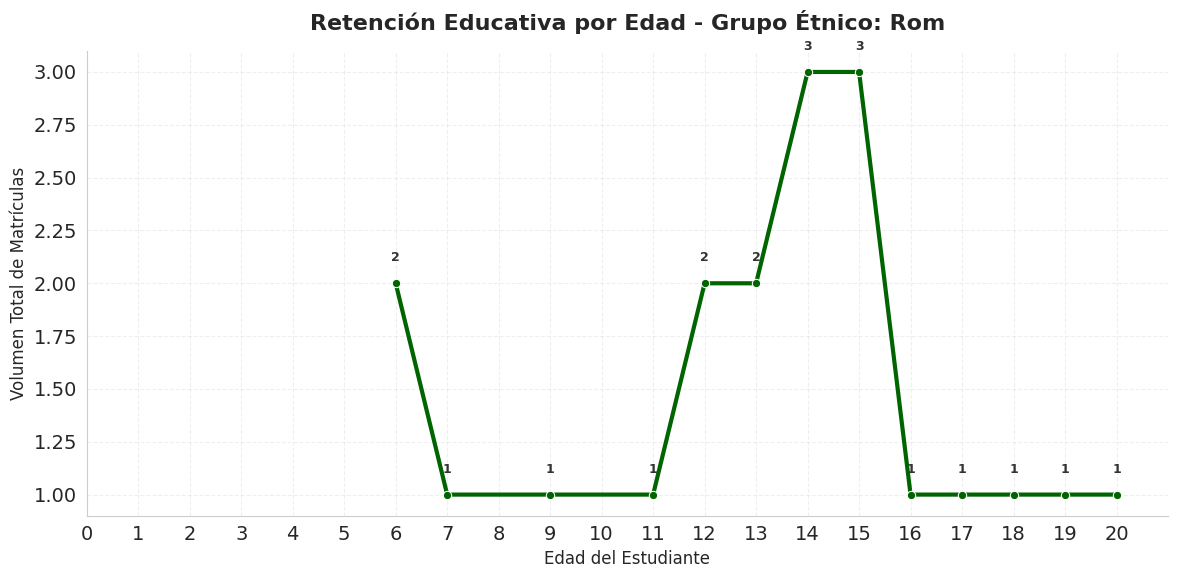

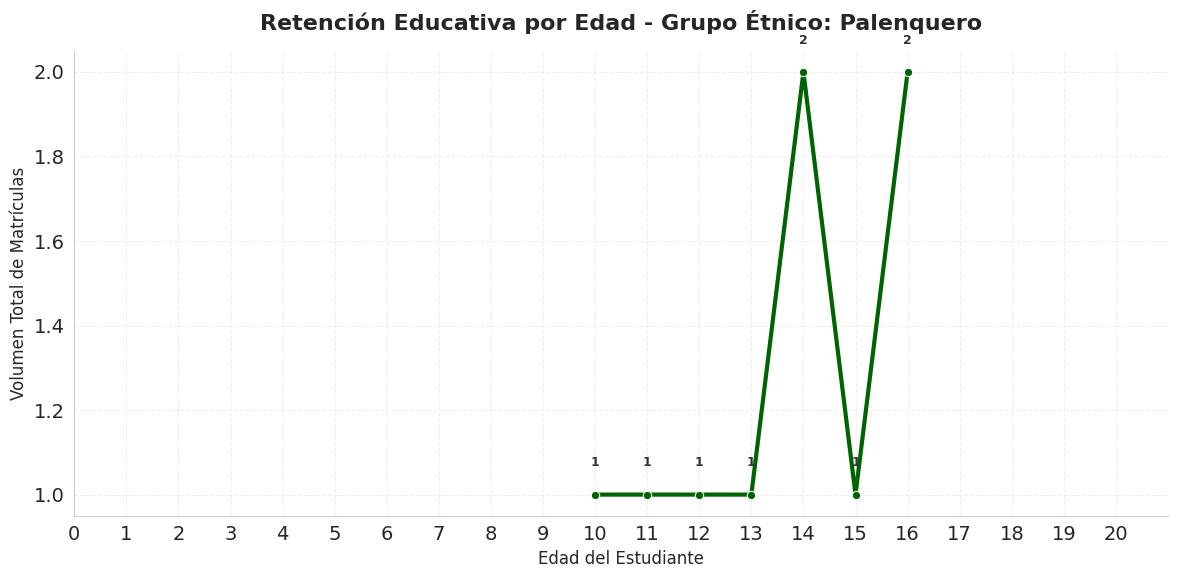

In [ ]:
#-------------------
# Graficos
#-------------------

# grafico de curvatura de matriculacion por edad

matriculacion_edad = matricula_b5_df.groupby('edad').size().reset_index(name='total_matriculados')
matriculacion_edad = matriculacion_edad[matriculacion_edad['edad'] <= 20].copy()
plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=matriculacion_edad,
    x='edad',
    y='total_matriculados',
    marker='o',
    color='firebrick',
    linewidth=3
)

for x, y in zip(matriculacion_edad['edad'], matriculacion_edad['total_matriculados']):
    if 0 <= x <= 20:
      ax.text(
          x = x,
          y = y + (matriculacion_edad['total_matriculados'].max() * 0.02), # Margen dinámico
          s = f'{y:,}',
          ha = 'center',
          va = 'bottom',
          fontsize = 9,
          fontweight = 'bold',
          color = '#333333'
    )

plt.title("Curva de Retención Educativa por Edad", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Edad del Estudiante", fontsize=12)
plt.ylabel("Volumen Total de Matrículas", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# grafico de curvatura de matriculacion por genero
matriculacion_edad_genero = matricula_b5_df.groupby(['edad','genero']).size().reset_index(name='total_matriculados')
matriculacion_edad_genero = matriculacion_edad_genero[matriculacion_edad_genero['edad'] <= 20].copy()

generos = matriculacion_edad_genero['genero'].unique()

for gen in generos:
    df_gen = matriculacion_edad_genero[matriculacion_edad_genero['genero'] == gen]

    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(
        data=df_gen,
        x='edad',
        y='total_matriculados',
        marker='o',
        color='firebrick',
        linewidth=3
    )

    for x, y in zip(df_gen['edad'], df_gen['total_matriculados']):
        ax.text(
            x = x,
            y = y + (df_gen['total_matriculados'].max() * 0.03),
            s = f'{y:,}',
            ha = 'center',
            va = 'bottom',
            fontsize = 9,
            fontweight = 'bold',
            color = '#333333'
        )

    plt.title(f"Retención Educativa por Edad - Género: {gen}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Edad del Estudiante", fontsize=12)
    plt.ylabel("Volumen Total de Matrículas", fontsize=12)

    plt.xlim(0, 21)
    plt.xticks(range(0, 21))

    plt.grid(True, linestyle="--", alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

'''
plt.title("Curva de Retención Educativa por edad", fontsize=14, fontweight='bold')
plt.xlabel("Edad del Estudiante", fontsize=12)
plt.ylabel("Volumen Total de Matrículas", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
'''

# retencion educativa por zona
matriculacion_edad_zona = matricula_b5_df.groupby(['edad', 'zona']).size().reset_index(name='total_matriculados')
matriculacion_edad_zona = matriculacion_edad_zona[matriculacion_edad_zona['edad'] <= 20].copy()

zonas = matriculacion_edad_zona['zona'].unique()

for zona in zonas:
    df_zona = matriculacion_edad_zona[matriculacion_edad_zona['zona'] == zona]

    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(
        data=df_zona,
        x='edad',
        y='total_matriculados',
        marker='o',
        color='navy',
        linewidth=3
)

    for x, y in zip(df_zona['edad'], df_zona['total_matriculados']):
        ax.text(
            x = x,
            y = y + (df_zona['total_matriculados'].max() * 0.03),
            s = f'{y:,}',
            ha = 'center',
            va = 'bottom',
            fontsize = 9,
            fontweight = 'bold',
            color = '#333333'
        )

    plt.title(f"Retención Educativa por Edad - Zona: {zona}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Edad del Estudiante", fontsize=12)
    plt.ylabel("Volumen Total de Matrículas", fontsize=12)

    plt.xlim(0, 21)
    plt.xticks(range(0, 21))

    plt.grid(True, linestyle="--", alpha=0.3)
    sns.despine() # Estilo ejecutivo
    plt.tight_layout()
    plt.show()

# retencion educativa por grupo etnico
matriculacion_edad_etnia = matricula_b5_df.groupby(['edad', 'grupo_etnico']).size().reset_index(name='total_matriculados')
matriculacion_edad_etnia = matriculacion_edad_etnia[matriculacion_edad_etnia['edad'] <= 20].copy()

etnias = matriculacion_edad_etnia['grupo_etnico'].unique()

for etnia in etnias:
    df_etnia = matriculacion_edad_etnia[matriculacion_edad_etnia['grupo_etnico'] == etnia]

    plt.figure(figsize=(12, 6))

    ax = sns.lineplot(
        data=df_etnia,
        x='edad',
        y='total_matriculados',
        marker='o',
        color='darkgreen',
        linewidth=3
    )

    for x, y in zip(df_etnia['edad'], df_etnia['total_matriculados']):
        ax.text(
            x = x,
            y = y + (df_etnia['total_matriculados'].max() * 0.03),
            s = f'{y:,}',
            ha = 'center',
            va = 'bottom',
            fontsize = 9,
            fontweight = 'bold',
            color = '#333333'
        )

    plt.title(f"Retención Educativa por Edad - Grupo Étnico: {etnia}", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Edad del Estudiante", fontsize=12)
    plt.ylabel("Volumen Total de Matrículas", fontsize=12)

    plt.xlim(0, 21)
    plt.xticks(range(0, 21))

    plt.grid(True, linestyle="--", alpha=0.3)
    sns.despine()
    plt.tight_layout()
    plt.show()

dataset con indicadores economicos, infraestructura y calidad de la educación

departamento
amazonas                                                    12
antioquia                                                   12
arauca                                                      12
archipiélago de san andrés, providencia y santa catalina    12
atlántico                                                   12
bogotá, d,c,                                                 1
bogotá, d.c.                                                11
bolívar                                                     12
boyacá                                                      12
caldas                                                      12
caquetá                                                     12
casanare                                                    12
cauca                                                       12
cesar                                                       12
chocó                                                       12
cundinamarca                              

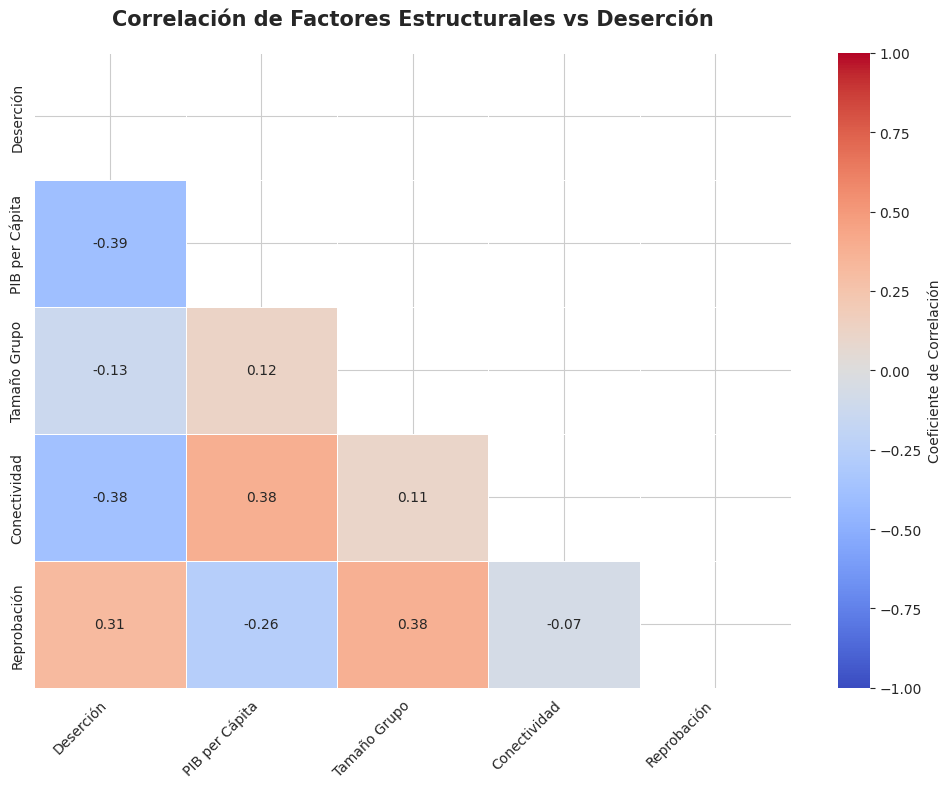

In [ ]:
from scipy import stats

matricula_departamento_df['departamento'] = matricula_departamento_df['departamento'].replace({
    'bogotá, d,c,': 'bogotá, d.c.',
    'BOGOTÁ, D,C,': 'bogotá, d.c.',
    'BOGOTÁ, D.C.': 'bogotá, d.c.'
})

matricula_departamento_df['departamento'] = matricula_departamento_df['departamento'].str.lower()

conteo_temporal = matricula_departamento_df.groupby('departamento')['año'].count()
print(conteo_temporal)


conteo_temporal = idh_df.groupby('departamento')['año'].count()
print(conteo_temporal)
idh_df['departamento'] = idh_df['departamento'].str.lower()



master_df = pd.merge(
    matricula_departamento_df,
    idh_df,
    on=['departamento', 'año'],
    how='inner'
)

columnas_interes = [
    'departamento',
    'año',
    'deserción',
    'índice_estandarizado_de_pib_per_cápita_minero_ppa',
    'tamaño_promedio_de_grupo',
    'sedes_conectadas_a_internet',
    'reprobación',
    'índice_de_desarrollo_humano'
]

df_causas = master_df[columnas_interes].copy()

print(df_causas.describe())

# Validar si tengo valores nulos y el tipo de datos por columna
print('Recuento devalores nulos')
print(matricula_departamento_df.isnull().sum())
duplicados_totales = df_causas.duplicated().sum()
print(f"Número total de filas duplicadas: {df_causas}")

print(df_causas['año'].unique())
conteo_temporal = df_causas.groupby('departamento')['año'].count()
print(conteo_temporal)

#correlacion de causas estructurales
cols_para_correlacion = [
    'deserción',
    'índice_estandarizado_de_pib_per_cápita_minero_ppa',
    'tamaño_promedio_de_grupo',
    'sedes_conectadas_a_internet',
    'reprobación'
]

etiquetas_cortas = [
    'Deserción',
    'PIB per Cápita',
    'Tamaño Grupo',
    'Conectividad',
    'Reprobación'
]

correlation = df_causas[cols_para_correlacion].corr()


plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5,
    mask=mask,
    xticklabels=etiquetas_cortas,
    yticklabels=etiquetas_cortas,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)

plt.title("Correlación de Factores Estructurales vs Deserción", fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotamos etiquetas para que no choquen
plt.tight_layout()
plt.show()

df_causas
df_causas.to_csv(f'{ruta_carpeta}variablesestructurales_dataset_clean.csv', index=False, encoding='utf-8-sig')